# Trabajo práctico integrador - Grupo 4
Este es el proceso de minería de datos para obtener el sistema recomendador utilizado

## Fase 1 - Entendimiento del negocio

### Actividad 1.1: antecedentes

### Contexto del Negocio y Requerimientos del Comitente
El comitente posee un sistema desarrollado sobre una web, con un carrusel que
muestra a los usuarios juegos que pueden interesarle al cliente, siendo actualmente
de manera aleatoria. <br>
El catalogo esta fomado por 100 juegos, esto no va a cambiar, ya que se baso en metacritics para su seleccion y le ha surtido efecto.<br>
No obstante, recibe muchos usuarios nuevos todo el tiempo y que, con un promedio de compra alrededor de 7 u 8 artículos cada uno, a lo sumo algunos comprarán 10, pero puede cambiar en cualquier momento, si la situación mejora.<br>
<br>
El objetivo actual es mejorar esta situacion mejorando el sistema de recomendaciones que posee la pagina, basandose en intereses por generos de los usuarios

### Actividad 1.2 Evaluar la situacion actual

## Fase 2 - Entendimiento de los datos

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Leon\Desktop\Proyecto integrador cdd\data-science\database\games.csv")

Empezamos por revisar el data frame asi logramos conocer sus filas y columnas

In [5]:
df

,id,title,releaseDate,rating,genres,description,platforms,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,platform_metascores,developer,publisher,platform_list,genre_list
0,1300540639,Outer Wilds: Echoes of the Eye,2021-09-28,NaN,"Open-World Action, Action RPG, Linear Action A...",A strange satellite photo that can’t be explai...,PC,82.0,8,Generally favorable,89,204,Generally favorable,82,"Mobius Digital, LLC",Annapurna Interactive,['PC'],"['Open-World Action', 'Action RPG', 'Linear Ac..."
1,1300473095,Yakuza Kiwami 2,2018-08-28,M,"Open-World Action, FPS, Survival",Kazuma Kiryu thought his Tojo Clan days were b...,"PlayStation 4,PC,Xbox One,Nintendo Switch 2",85.0,69,Generally favorable,84,688,Generally favorable,"85,82,88,83",Ryu ga Gotoku Studios,Sega,"['PlayStation 4', 'PC', 'Xbox One', 'Nintendo ...","['Open-World Action', 'FPS', 'Survival']"
2,1300536274,Lost Judgment,2021-09-21,M,"Open-World Action, FPS, Survival","SEIZE THE TRUTH - December 2021, Tokyo distric...","PlayStation 5,Xbox Series X,PlayStation 4,PC",82.0,80,Generally favorable,85,416,Generally favorable,"82,80,83,84",Ryu ga Gotoku Studios,Sega,"['PlayStation 5', 'Xbox Series X', 'PlayStatio...","['Open-World Action', 'FPS', 'Survival']"
3,1300069209,Darksiders II,2012-08-14,M,"Open-World Action, Linear Action Adventure, FPS","Awakened by the End of Days, Death, the most f...","Xbox 360,PlayStation 3,PC,Wii U",83.0,63,Generally favorable,81,683,Generally favorable,"83,84,81,85",Vigil Games,"THQ,Spike Chunsoft","['Xbox 360', 'PlayStation 3', 'PC', 'Wii U']","['Open-World Action', 'Linear Action Adventure..."
4,1300491974,Reventure,2019-10-08,T,"Open-World Action, Linear Action Adventure, FPS",The one and only non-linear adventure with 100...,"PC,Nintendo Switch",83.0,7,Generally favorable,76,47,Generally favorable,"84,83",Pixelatto,Pixelatto,"['PC', 'Nintendo Switch']","['Open-World Action', 'Linear Action Adventure..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1300145158,Dead Space 3,2013-02-05,M,"Linear Action Adventure, Action RPG, Open-Worl...",Dead Space 3 embodies deep space terror. Playe...,"PlayStation 3,Xbox 360,PC",78.0,68,Generally favorable,64,997,Mixed or average,"76,78,78",Visceral Games,Electronic Arts,"['PlayStation 3', 'Xbox 360', 'PC']","['Linear Action Adventure', 'Action RPG', 'Ope..."
96,1300459505,Little Nightmares,2017-04-28,T,"Linear Action Adventure, Open-World Action, FPS","Immerse yourself in Little Nightmares, a dark ...","PlayStation 4,Xbox One,PC",78.0,52,Generally favorable,80,1217,Generally favorable,"78,83,81",Tarsier Studios,Bandai Namco Games,"['PlayStation 4', 'Xbox One', 'PC']","['Linear Action Adventure', 'Open-World Action..."
97,1300237117,Volume,2015-08-18,T,"Linear Action Adventure, Action RPG, Open-Worl...",Robert Locksley is a petty thief who happens u...,"PC,PlayStation 4,PlayStation Vita",80.0,34,Generally favorable,73,58,Mixed or average,"80,71,86",Mike Bithell,Mike Bithell,"['PC', 'PlayStation 4', 'PlayStation Vita']","['Linear Action Adventure', 'Action RPG', 'Ope..."
98,1300127177,Alan Wake's American Nightmare,2012-02-22,T,"Linear Action Adventure, Action RPG, Open-Worl...","After the events of Alan Wake, our eponymous h...","Xbox 360,PC",76.0,72,Generally favorable,74,295,Mixed or average,"76,73",Remedy Entertainment,Microsoft Game Studios,"['Xbox 360', 'PC']","['Linear Action Adventure', 'Action RPG', 'Ope..."


Utilizamos .info y .info().sum() para conocer la informacion de las columnas del data frame, gracias a esto podemos ver que en rating se encuentran 22 datos nulos, los cuales no afectaran a nuestro analisis, ya que no es una columna que utilizaremos para el sistema recomendador

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   100 non-null    int64  
 1   title                100 non-null    object 
 2   releaseDate          100 non-null    object 
 3   rating               78 non-null     object 
 4   genres               100 non-null    object 
 5   description          100 non-null    object 
 6   platforms            100 non-null    object 
 7   metascore            100 non-null    float64
 8   metascore_count      100 non-null    int64  
 9   metascore_sentiment  100 non-null    object 
 10  userscore            100 non-null    int64  
 11  userscore_count      100 non-null    int64  
 12  userscore_sentiment  100 non-null    object 
 13  platform_metascores  100 non-null    object 
 14  developer            100 non-null    object 
 15  publisher            100 non-null    obje

In [5]:
df.isnull().sum()

id                      0
title                   0
releaseDate             0
rating                 22
genres                  0
description             0
platforms               0
metascore               0
metascore_count         0
metascore_sentiment     0
userscore               0
userscore_count         0
userscore_sentiment     0
platform_metascores     0
developer               0
publisher               0
platform_list           0
genre_list              0
dtype: int64

Se procede a desglosar la columna genres para conocer todos los generos contemplados en el dataframe, primero revisamos que contiene la columna, luego realizamos una pequeña funcion para saber cada tipo individual de genero y cuantas veces se repite este.

In [6]:
df["genres"].value_counts

<bound method IndexOpsMixin.value_counts of 0     Open-World Action, Action RPG, Linear Action A...
1                      Open-World Action, FPS, Survival
2                      Open-World Action, FPS, Survival
3       Open-World Action, Linear Action Adventure, FPS
4       Open-World Action, Linear Action Adventure, FPS
                            ...                        
95    Linear Action Adventure, Action RPG, Open-Worl...
96      Linear Action Adventure, Open-World Action, FPS
97    Linear Action Adventure, Action RPG, Open-Worl...
98    Linear Action Adventure, Action RPG, Open-Worl...
99      Linear Action Adventure, FPS, Open-World Action
Name: genres, Length: 100, dtype: object>

In [8]:
generos_expandidos = df['genres'].dropna().str.split(',').explode().str.strip()

conteo_generos = generos_expandidos.value_counts()

for genero, cantidad in conteo_generos.items():
    print(f"{genero}: {cantidad}")

Open-World Action: 89
FPS: 69
Action RPG: 67
Linear Action Adventure: 41
Survival: 34


Como parte de la fase de Comprensión de los Datos, se llevó a cabo un análisis bivariado para explorar la relación entre las calificaciones de la crítica especializada (metascore) y la recepción del público general (userscore)

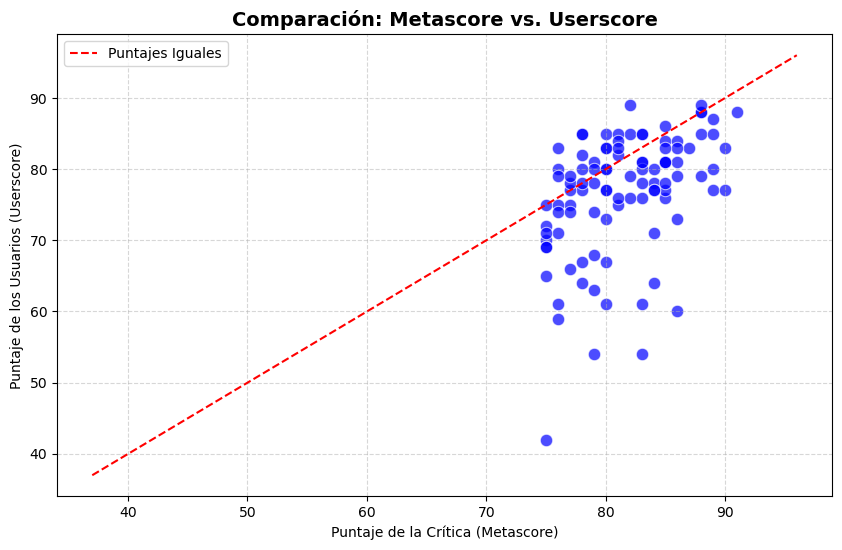

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='metascore', y='userscore', color='blue', alpha=0.7, s=80)

minimo = min(df['metascore'].min(), df['userscore'].min()) - 5
maximo = max(df['metascore'].max(), df['userscore'].max()) + 5
plt.plot([minimo, maximo], [minimo, maximo], color='red', linestyle='--', label='Puntajes Iguales')

plt.title('Comparación: Metascore vs. Userscore', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje de la Crítica (Metascore)')
plt.ylabel('Puntaje de los Usuarios (Userscore)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Al evaluar el gráfico de dispersión resultante, se evidencia una clara tendencia central. En su gran mayoría, los puntajes otorgados por Metacritic no distan significativamente de las valoraciones de los usuarios. Esta alineación sugiere que no existe una polarización extrema en la muestra analizada; es decir, los títulos bien valorados por la prensa tienden a replicar ese mismo éxito entre la comunidad de jugadores.

Con el objetivo de identificar si el género de un videojuego influye significativamente en la percepción de la crítica especializada, se generó un diagrama de cajas cruzando la variable numérica metascore con las categorías individuales extraídas de la columna genres.

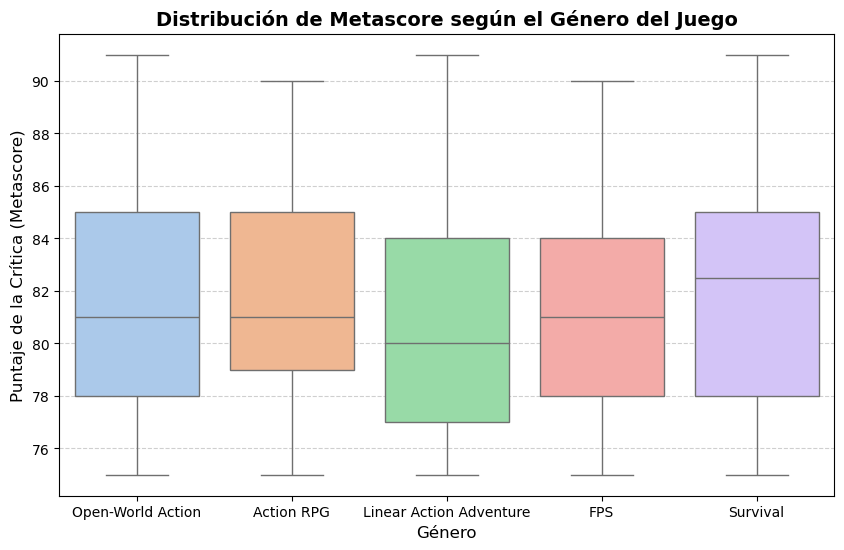

In [14]:
df_expandido = df.assign(genero_individual=df['genres'].dropna().str.split(',')).explode('genero_individual')

df_expandido['genero_individual'] = df_expandido['genero_individual'].str.strip()

df_expandido = df_expandido.dropna(subset=['metascore', 'genero_individual'])


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_expandido, 
    x='genero_individual', 
    y='metascore', 
    hue='genero_individual', 
    palette='pastel', 
    legend=False
)

plt.title('Distribución de Metascore según el Género del Juego', fontsize=14, fontweight='bold')
plt.xlabel('Género', fontsize=12)
plt.ylabel('Puntaje de la Crítica (Metascore)', fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.show()

El hallazgo más destacable es la consistencia de las puntuaciones en todos los géneros. La mayoria de las medianas de Metascore oscilan en un rango muy estrecho ,entre 80 y 82 puntos.<br>
Survival destaca ligeramente como el género con la mediana de aprobación más alta, mostrando una concentración fuerte de juegos exitosos en la crítica.

Para conocer la relación entre la cantidad de géneros presentes por plataforma, procederemos a utilizar un mapa de calor. Dado que las variables plataformas y generos contienen múltiples valores combinados por celda, fue necesario aplicar una doble expansión en los datos para obtener una tabla de contingencia precisa. Esta visualización nos permite identificar visualmente las intersecciones con mayor volumen de juegos a través de la intensidad del color.

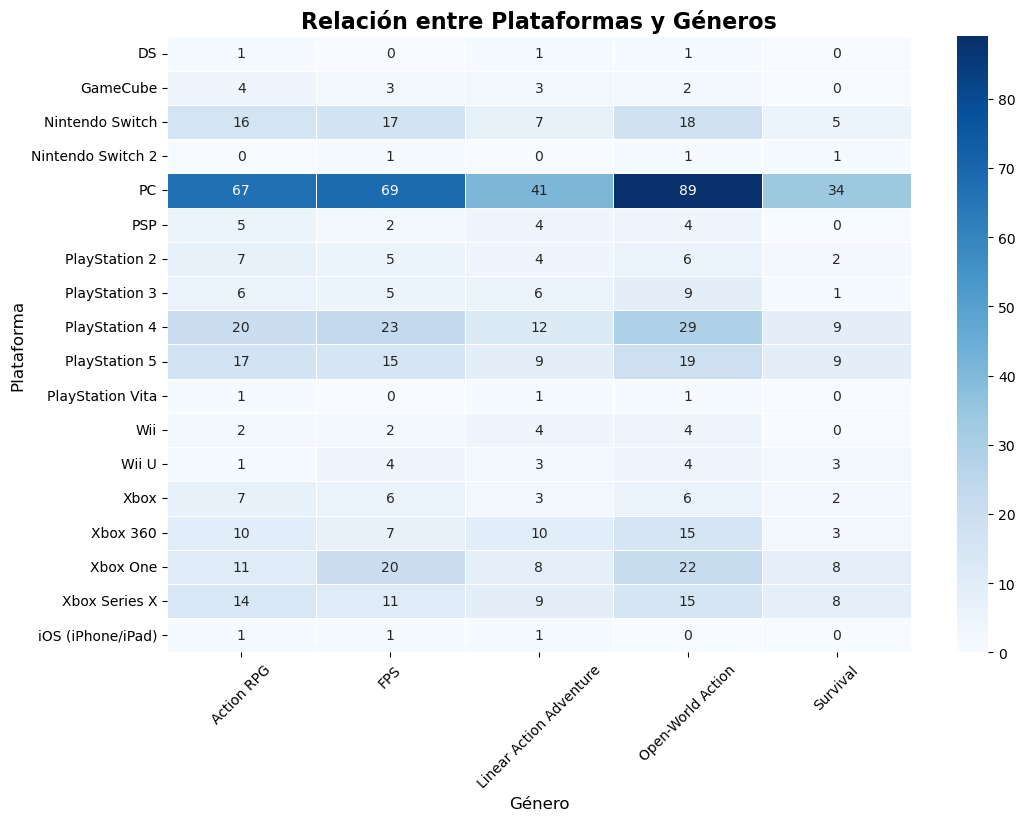

In [15]:
df_gen = df.assign(genero=df['genres'].dropna().str.split(',')).explode('genero')
df_gen['genero'] = df_gen['genero'].str.strip()

df_plat_gen = df_gen.assign(plataforma=df_gen['platforms'].dropna().str.split(',')).explode('plataforma')
df_plat_gen['plataforma'] = df_plat_gen['plataforma'].str.strip()

tabla_cruzada = pd.crosstab(df_plat_gen['plataforma'], df_plat_gen['genero'])


plt.figure(figsize=(12, 8)) # Hacemos el lienzo un poco más grande

sns.heatmap(tabla_cruzada, annot=True, cmap='Blues', fmt='d', linewidths=.5)

plt.title('Relación entre Plataformas y Géneros', fontsize=16, fontweight='bold')
plt.ylabel('Plataforma', fontsize=12)
plt.xlabel('Género', fontsize=12)

plt.xticks(rotation=45) 

plt.show()

* **Dominancia de PC:** El mapa de calor revela una fuerte asimetría en la distribución. La fila correspondiente a **"PC"** concentra la máxima intensidad en absolutamente todos los géneros, destacando especialmente en *Open-World Action* y *FPS*. Esto indica que la inmensa mayoría de los juegos de la muestra están disponibles en PC, independientemente de en qué otras consolas se hayan lanzado.

* **Distribución en consolas modernas:** Consolas como la *Nintendo Switch*, *PlayStation 4* y *PlayStation 5* muestran una distribución secundaria sólida, acompañando las tendencias generales. Sus catálogos en esta muestra se apoyan fuertemente en los géneros *FPS* y *Open-World Action*, mientras que el género *Survival* tiene una adopción considerablemente menor en estas plataformas.

* **Plataformas minoritarias:** Se observa una gran cantidad de plataformas clásicas o portátiles que registran frecuencias marginales.

## Fase 3 - Preparación de los datos

Se procede a disminuir las columnas del data frame, asi poseemos un data frame util (dfu) con el cual trabajar con comodidad. Las columnas que dejaremos seran las siguientes: id, title, genres, description, platforms, metascore, userscore

In [11]:
dfu = df[['id', 'title', 'genres', 'description', 'platforms', 'metascore', 'userscore']]
dfu.head()

,id,title,genres,description,platforms,metascore,userscore
0,1300540639,Outer Wilds: Echoes of the Eye,"Open-World Action, Action RPG, Linear Action A...",A strange satellite photo that can’t be explai...,PC,82.0,89
1,1300473095,Yakuza Kiwami 2,"Open-World Action, FPS, Survival",Kazuma Kiryu thought his Tojo Clan days were b...,"PlayStation 4,PC,Xbox One,Nintendo Switch 2",85.0,84
2,1300536274,Lost Judgment,"Open-World Action, FPS, Survival","SEIZE THE TRUTH - December 2021, Tokyo distric...","PlayStation 5,Xbox Series X,PlayStation 4,PC",82.0,85
3,1300069209,Darksiders II,"Open-World Action, Linear Action Adventure, FPS","Awakened by the End of Days, Death, the most f...","Xbox 360,PlayStation 3,PC,Wii U",83.0,81
4,1300491974,Reventure,"Open-World Action, Linear Action Adventure, FPS",The one and only non-linear adventure with 100...,"PC,Nintendo Switch",83.0,76


procedemos a generar una columna por genero, la cual se le colocara un 1 si el juego posee ese genero en genres y un 0 si no lo posee 

In [12]:
dfu = dfu.copy()

dfu['genres_limpios'] = dfu['genres'].apply(lambda x: '|'.join([g.strip() for g in x.split(',')]))

columnas_generos = dfu['genres_limpios'].str.get_dummies(sep='|')

dfu = pd.concat([dfu, columnas_generos], axis=1)

dfu = dfu.drop(columns=['genres', 'genres_limpios'])

dfu.head()

,id,title,description,platforms,metascore,userscore,Action RPG,FPS,Linear Action Adventure,Open-World Action,Survival
0,1300540639,Outer Wilds: Echoes of the Eye,A strange satellite photo that can’t be explai...,PC,82.0,89,1,0,1,1,0
1,1300473095,Yakuza Kiwami 2,Kazuma Kiryu thought his Tojo Clan days were b...,"PlayStation 4,PC,Xbox One,Nintendo Switch 2",85.0,84,0,1,0,1,1
2,1300536274,Lost Judgment,"SEIZE THE TRUTH - December 2021, Tokyo distric...","PlayStation 5,Xbox Series X,PlayStation 4,PC",82.0,85,0,1,0,1,1
3,1300069209,Darksiders II,"Awakened by the End of Days, Death, the most f...","Xbox 360,PlayStation 3,PC,Wii U",83.0,81,0,1,1,1,0
4,1300491974,Reventure,The one and only non-linear adventure with 100...,"PC,Nintendo Switch",83.0,76,0,1,1,1,0


## Fase 4 - Modelado
BLA

## Fase 5 - Evaluación
BLA

## Fase 6 - Despliegue
BLA